# Exercises for Chapter 19, Causal inference using regression on the treatment variable

In [30]:
import os
import sys

import arviz
import bambi
import numpy
import pandas

from matplotlib import pyplot

sys.path.append(os.path.abspath("/home/bgawalt/ros"))
import bg_ros

In [2]:
prng_builder = bg_ros.PRNGBuilder('Exercises for Chapter 19, Causal inference using regression on the treatment variable')

## 19.4, Pre-test and post-test

> 100 students are given a pre-test, then a treatment or control is randomly
> assigned to each, then they get a post-test.  Given the following regression
> model:
>
> $$\text{post\_test} = a + b \cdot \text{pre\_test} + \theta \cdot z + \text{error},$$
>
> where $z = 1$ for treated units and 0 for controls.  Further suppose that
> `pre_test` has mean 40 and standard deviation 15.  Suppose $b = 0.7$ and
> $\theta = 10$ and the mean for `post_test` is 50 for the students in the
> control group. Further suppose that the residual standard deviation of the 
> regression is 10.
>
> (a) Determine a.
>
> (b) What is the standard deviation of the post-test scores for the students in
>     the control group?
>
> (c) What are the mean and standard deviation of the post-test scores in the
>     treatment group?

In [3]:
# E[post] = a + b E[pre]
a = 50 - (0.7 * 40)
sd_y0 = 0.7 * 15 + 10
mu_y1 = a + (0.7 * 40) + 10
print(f'a = {a:0.2f}')
print(f'sd_y0 = {sd_y0:0.2f}')
print(f'mu_y1 = {mu_y1:0.2f}')

a = 22.00
sd_y0 = 20.50
mu_y1 = 60.00


## 19.6, Sketching the regression model for causal inference

> Assume that linear regression is appropriate for the regression of an outcome,
> $y$, on treatment indicator, $z$, and a single confounding covariate, $x$.
> With pen on paper, sketch hypothetical data (plotting $y$ versus $x$, with
> treated and control units indicated by circles and dots, respectively) and
> regression lines (for treatment and control group) that represent each of the
> following situations:
>
> (a) No treatment effect,
> 
> (b) Constant treatment effect,
>
> (c) Treatment effect increasing with $x$.

In [4]:
rng = prng_builder.new('19.6, Sketching the regression model for causal inference')

In [5]:
def fake_series(
    rng: numpy.random.Generator,
    constant_effect: float = 0,
    covariate_effect: float = 0
) -> (numpy.ndarray, numpy.ndarray):
    n = 40
    xs = rng.uniform(low=0, high=10, size=n)
    ys = 20 + constant_effect + (-3 + covariate_effect) * xs + rng.normal(scale=2, size=n)
    return (xs, ys)

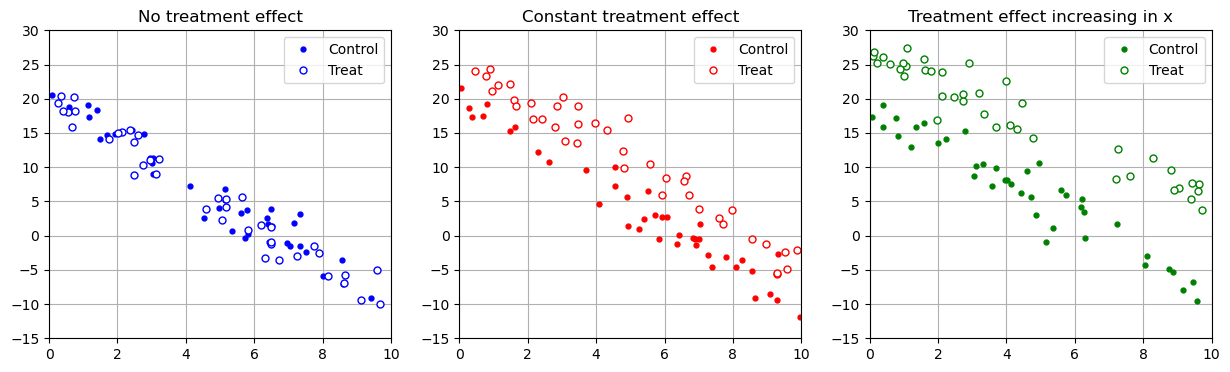

In [6]:
fig, axs = pyplot.subplots(nrows=1, ncols=3, figsize=(15, 4))

x_c, y_c = fake_series(rng)
x_t, y_t = fake_series(rng)
ax = axs[0]
ax.set_title('No treatment effect')
color = 'b'

ax.plot(x_c, y_c, mec=color, mfc=color, linewidth=0, marker='.', markersize=7, label='Control')
ax.plot(x_t, y_t, mec=color, mfc='w', linewidth=0, marker='o', markersize=5, label='Treat')
ax.grid()
ax.set_axisbelow(True)
ax.set_ylim(-15, 30)
ax.set_xlim(0, 10)
ax.legend()

x_c, y_c = fake_series(rng)
x_t, y_t = fake_series(rng, constant_effect=6)
ax = axs[1]
ax.set_title('Constant treatment effect')
color = 'r'

ax.plot(x_c, y_c, mec=color, mfc=color, linewidth=0, marker='.', markersize=7, label='Control')
ax.plot(x_t, y_t, mec=color, mfc='w', linewidth=0, marker='o', markersize=5, label='Treat')
ax.grid()
ax.set_axisbelow(True)
ax.set_ylim(-15, 30)
ax.set_xlim(0, 10)
ax.legend()

x_c, y_c = fake_series(rng)
x_t, y_t = fake_series(rng, constant_effect=6, covariate_effect=1)
ax = axs[2]
ax.set_title('Treatment effect increasing in x')
color = 'g'

ax.plot(x_c, y_c, mec=color, mfc=color, linewidth=0, marker='.', markersize=7, label='Control')
ax.plot(x_t, y_t, mec=color, mfc='w', linewidth=0, marker='o', markersize=5, label='Treat')
ax.grid()
ax.set_axisbelow(True)
ax.set_ylim(-15, 30)
ax.set_xlim(0, 10)
ax.legend()

## 19.7, Linearity assumptions and causal inference

> Consider a study with an outcome, $y$, a treatment indicator, $z$, and a
> single confounding covariate, $x$. Draw a scatterplot of treatment and control
> observations that demonstrates each of the following:
>
> (a) A scenario where the difference in means estimate would not capture the
>     true treatment effect but a regression of $y$ on $x$ and $z$ would yield
>     the correct estimate.
>
> (b) A scenario where a linear regression would yield the wrong estimate but a
>     nonlinear regression would yield the correct estimate.

In [7]:
rng = prng_builder.new('19.7, Linearity assumptions and causal inference')

### 19.7(a)

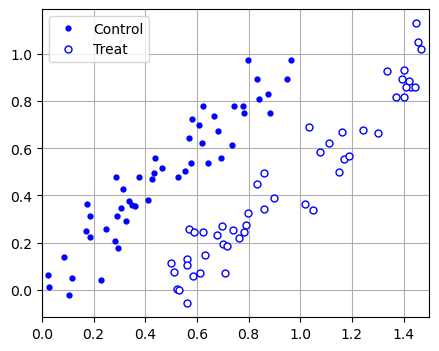

In [8]:
xs_c = rng.uniform(low=0, high=1, size=50)
ys_c = xs_c + rng.normal(scale=0.1, size=50)
xs_t = rng.uniform(low=0.5, high=1.5, size=50)
ys_t = xs_t - 0.5 + rng.normal(scale=0.1, size=50)

fig = pyplot.figure(figsize=(5, 4))
ax = fig.gca()
color = 'b'

ax.plot(xs_c, ys_c, mec=color, mfc=color, linewidth=0, marker='.', markersize=7, label='Control')
ax.plot(xs_t, ys_t, mec=color, mfc='w', linewidth=0, marker='o', markersize=5, label='Treat')
ax.grid()
ax.set_axisbelow(True)
ax.set_xlim(0, 1.5)
ax.legend()


In [9]:
delta_y = numpy.mean(ys_t) - numpy.mean(ys_c)
print(f'Diff. in means: {delta_y:0.2f}')

Diff. in means: -0.04


In [10]:
xs = [xi for xi in xs_c] + [xi for xi in xs_t]
ys = [yi for yi in ys_c] + [yi for yi in ys_t]
zs = numpy.array([0 for _ in range(50)] + [1 for _ in range(50)])
df_7a = pandas.DataFrame(data={'x': xs, 'y': ys, 'z': zs})

In [11]:
model_7a = bambi.Model('y ~ x + z', df_7a)
model_7a_fit = model_7a.fit()
print(bg_ros.bambi_markdown(model_7a_fit, ['x', 'z']))

Initializing NUTS using jitter+adapt_diag...
/home/bgawalt/miniconda3/envs/ros_conda/lib/python3.14/site-packages/pytensor/link/c/cmodule.py:3004: UserWarning: PyTensor could not link to a BLAS installation. Operations that might benefit from BLAS will be severely degraded.
This usually happens when PyTensor is installed via pip. We recommend it be installed via conda/mamba/pixi instead.
Alternatively, you can use an experimental backend such as Numba or JAX that perform their own BLAS optimizations, by setting `pytensor.config.mode == 'NUMBA'` or passing `mode='NUMBA'` when compiling a PyTensor function.
For more options and details see https://pytensor.readthedocs.io/en/latest/troubleshooting.html#how-do-i-configure-test-my-blas-library
  warnings.warn(
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, x, z]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 8 seconds.


Coef.     | Mean   | s.e.
--------- | ------ | ------
sigma     | 0.09 | 0.01
Intercept | 0.04 | 0.02
x         | 0.95 | 0.03
z         | -0.49 | 0.02



### 19.7(b)

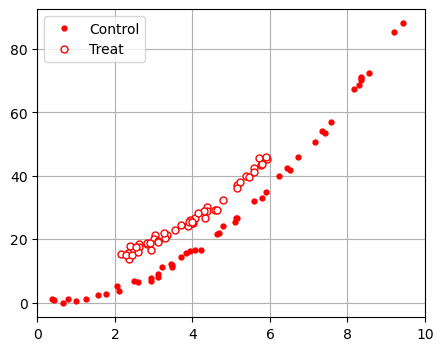

In [12]:
xs_c = rng.uniform(low=0, high=10, size=50)
ys_c = numpy.pow(xs_c, 2) + rng.normal(size=50)
xs_t = rng.uniform(low=2, high=6, size=50)
ys_t = 10 + numpy.pow(xs_t, 2) + rng.normal(size=50)

fig = pyplot.figure(figsize=(5, 4))
ax = fig.gca()
color = 'r'

ax.plot(xs_c, ys_c, mec=color, mfc=color, linewidth=0, marker='.', markersize=7, label='Control')
ax.plot(xs_t, ys_t, mec=color, mfc='w', linewidth=0, marker='o', markersize=5, label='Treat')
ax.grid()
ax.set_axisbelow(True)
ax.set_xlim(0, 10)
ax.legend()

In [13]:
df_7b = pandas.DataFrame(data={
    'y': [yi for yi in ys_c] + [yi for yi in ys_t],
    'x': [xi for xi in xs_c] + [xi for xi in xs_t],
    'x2': [xi * xi for xi in xs_c] + [xi * xi for xi in xs_t],
    'z': [0 for _ in range(50)] + [1 for _ in range(50)],
})

In [14]:
model_7b_bad = bambi.Model('y ~ x + z', df_7b)
model_7b_bad_fit = model_7b_bad.fit()
print(bg_ros.bambi_markdown(model_7b_bad_fit, ['x', 'z']))

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, x, z]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 8 seconds.


Coef.     | Mean   | s.e.
--------- | ------ | ------
sigma     | 4.95 | 0.36
Intercept | -15.77 | 1.34
x         | 9.44 | 0.24
z         | 5.66 | 1.01



In [15]:
model_7b_good = bambi.Model('y ~ x + x2 + z', df_7b)
model_7b_good_fit = model_7b_good.fit()
print(bg_ros.bambi_markdown(model_7b_good_fit, ['x', 'x2', 'z']))

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, x, x2, z]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 9 seconds.


Coef.     | Mean   | s.e.
--------- | ------ | ------
sigma     | 0.97 | 0.07
Intercept | 0.09 | 0.42
x         | -0.10 | 0.20
x2        | 1.01 | 0.02
z         | 10.21 | 0.22



## 19.8, Messy randomization

> The
> [folder `Cows` contains data](https://github.com/avehtari/ROS-Examples/tree/master/Cows)
> from an agricultural experiment that was conducted on 50 cows to estimate the
> effect of a feed additive on 6 outcomes related to the amount of milk fat
> produced by each cow.
>
> Four diets (treatments) were considered, corresponding to different levels of
> the additive, and three variables were recorded before treatment assignment:
> lactation number (seasons of lactation), age, and initial weight of the cow.
>
> Cows were initially assigned to treatments completely at random, and then the
> distributions of the three covariates were checked for balance across the
> treatment groups; several randomizations were tried, and the one that produced
> the "best" balance with respect to the three covariates was chosen.  The
> treatment depends only on fully observed covariates and not on unrecorded
> variables such as the physical appearances of the cows or the times at which
> the cows entered the study, because the decisions of whether to re-randomize
> are not explained.
>
> We shall consider different estimates of the effect of additive on the mean
> daily milk fat produced.

In [22]:
cows_parser = bg_ros.DATFileParser('/home/bgawalt/ros/datasets/cows.dat')
cows_df, err = cows_parser.parse(
    int_fields = [
        'age',
        'lactation',
        'initial_weight',  # Note: I swapped . for _ in the variable names
    ],
    float_fields = [
        'level',
        'milk',
        'fat',
    ],
)
print(err)
cows_df['milk_fat'] = cows_df['milk'] * cows_df['fat']
print(bg_ros.dataframe_describe_markdown(cows_df))

{}
|         | age | lactation | initial_weight | level | milk | fat | milk_fat
--------- | --- | --------- | -------------- | ----- | ---- | --- | --------
**count** | 50.00 | 50.00 | 50.00 | 50.00 | 50.00 | 50.00 | 50.00
**mean**  | 42.16 | 2.38 | 1258.06 | 0.15 | 59.54 | 3.58 | 213.09
**std**   | 18.59 | 1.32 | 181.21 | 0.11 | 9.36 | 0.48 | 45.38
**min**   | 21.00 | 1.00 | 900.00 | 0.00 | 40.24 | 2.65 | 130.81
**25%**   | 26.25 | 1.00 | 1118.75 | 0.10 | 53.11 | 3.27 | 179.85
**50%**   | 37.00 | 2.00 | 1266.50 | 0.15 | 59.52 | 3.46 | 207.32
**75%**   | 49.00 | 3.00 | 1369.00 | 0.20 | 66.66 | 3.91 | 248.43
**max**   | 95.00 | 6.00 | 1656.00 | 0.30 | 76.60 | 4.96 | 328.63



### 19.8(a)

> (a) Consider the simple regression of mean daily milk fat on the level of
>     additive.  Compute the estimated treatment effect and standard error, and
>     explain why this is not a completely appropriate analysis given the
>     randomization used.

In [23]:
cows1_model = bambi.Model('milk_fat ~ level', cows_df)
cows1_fit = cows1_model.fit()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, level]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 10 seconds.


In [25]:
print(bg_ros.bambi_markdown(cows1_fit, ['level']))

Coef.     | Mean   | s.e.
--------- | ------ | ------
sigma     | 44.37 | 4.59
Intercept | 194.43 | 10.50
level     | 124.45 | 56.23



### 19.8(b)

> (b) Add more predictors to the model. Explain your choice of which variables
>     to include.  Compare your estimated treatment effect to the result from
>     (a).

In [27]:
cows2_model = bambi.Model('milk_fat ~ level + age + lactation + initial_weight', cows_df)
cows2_fit = cows2_model.fit()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, level, age, lactation, initial_weight]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 11 seconds.


In [28]:
print(bg_ros.bambi_markdown(cows2_fit, ['level', 'age', 'lactation', 'initial_weight']))

Coef.          | Mean   | s.e.
-------------- | ------ | ------
sigma          | 36.22 | 3.80
Intercept      | 45.81 | 45.72
level          | 106.85 | 46.66
age            | -2.15 | 1.06
lactation      | 31.23 | 14.06
initial_weight | 0.13 | 0.05



### 19.8(c)

> (c) Repeat (b), this time considering additive level as a categorical
>     predictor with four levels.  Make a plot showing the estimate (and
>     standard error) of the treatment effect at each level, and also showing
>     the inference from the model fit in part (b).

In [35]:
cows_df['level_cat'] = [str(level) for level in cows_df['level']]
cows_df['level_cat'].unique()

<StringArray>
['0.0', '0.1', '0.2', '0.3']
Length: 4, dtype: str

In [36]:
cows3_model = bambi.Model('milk_fat ~ C(level_cat) + age + lactation + initial_weight', cows_df)
cows3_fit = cows3_model.fit()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, C(level_cat), age, lactation, initial_weight]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 9 seconds.


In [37]:
arviz.summary(cows3_fit)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma,37.022,4.068,30.061,44.847,0.068,0.066,3570.0,2781.0,1.0
Intercept,42.524,48.545,-46.064,133.299,0.688,0.801,4985.0,3133.0,1.0
C(level_cat)[0.1],17.520,15.076,-10.582,46.489,0.275,0.219,3009.0,3092.0,1.0
C(level_cat)[0.2],25.478,15.393,-3.497,53.906,0.277,0.229,3097.0,2495.0,1.0
C(level_cat)[0.3],32.705,16.063,2.198,62.390,0.301,0.241,2866.0,2730.0,1.0
age,-2.158,1.132,-4.311,-0.076,0.025,0.018,2044.0,2395.0,1.0
lactation,31.640,14.754,5.125,60.437,0.317,0.222,2161.0,2496.0,1.0
initial_weight,0.133,0.048,0.042,0.223,0.001,0.001,4536.0,3017.0,1.0


In [38]:
print(
    bg_ros.bambi_markdown(
        cows3_fit,
        [
            'C(level_cat)[0.1]',
            'C(level_cat)[0.2]',
            'C(level_cat)[0.3]',
            'age',
            'lactation',
            'initial_weight'
        ],
    )
)

Coef.             | Mean   | s.e.
----------------- | ------ | ------
sigma             | 37.02 | 4.07
Intercept         | 42.52 | 48.55
C(level_cat)[0.1] | 17.52 | 15.08
C(level_cat)[0.2] | 25.48 | 15.39
C(level_cat)[0.3] | 32.70 | 16.06
age               | -2.16 | 1.13
lactation         | 31.64 | 14.75
initial_weight    | 0.13 | 0.05



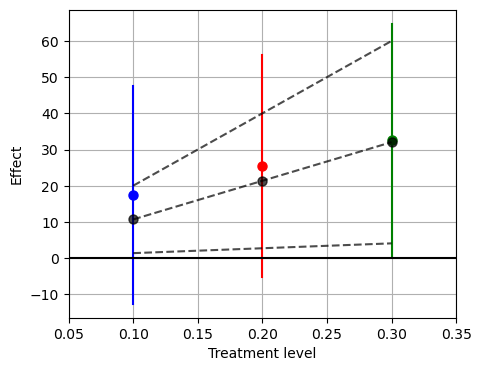

In [54]:
effects = {
    '0.1': (17.52, 15.08),
    '0.2': (25.48, 15.39),
    '0.3': (32.70, 16.06),
}
linear_coef = 106.85
linear_se = 46.66

fig = pyplot.figure(figsize=(5, 4))
ax = fig.gca()
for level, color in [('0.1', 'b'), ('0.2', 'r'), ('0.3', 'g')]:
    mu, sig = effects[level]
    flvl = float(level)
    ax.plot([flvl, flvl], [mu - 2 * sig, mu + 2 * sig], color + '-', markersize=0)
    ax.plot([flvl,], [mu,], color + '.', markersize=13)
ax.plot(
    [0.1, 0.2, 0.3],
    [linear_coef * x for x in [0.1, 0.2, 0.3]], 'k.--',
    markersize=13,
    alpha=0.7,
)
ax.plot(
    [0.1, 0.2, 0.3],
    [(linear_coef - 2 * linear_se) * x for x in [0.1, 0.2, 0.3]], 'k--',
    markersize=13,
    alpha=0.7,
)
ax.plot(
    [0.1, 0.2, 0.3],
    [(linear_coef + 2 * linear_se) * x for x in [0.1, 0.2, 0.3]], 'k--',
    markersize=13,
    alpha=0.7,
)
ax.set_xlim(0.05, 0.35)
ax.axhline(0, color='k')
ax.set_xlabel('Treatment level')
ax.set_ylabel('Effect')
ax.grid()
